# Empirical Evaluation of Incremental LOF for Anomaly Detection in Data Streams
Data Stream Mining – M.IA022, FEUP/FCUP*

---

**Algorithm under study:** Incremental Local Outlier Factor (LOF)  
**Baseline:** Half-Space Trees (HST)  
**Evaluation framework:** Prequential evaluation · multi-seed · synthetic + real streams

---

## Table of Contents

1. [Objective](#1-objective)
2. [Problem Context](#2-problem-context)
3. [Algorithms](#3-algorithms)
4. [Research Questions & Hypotheses](#4-research-questions--hypotheses)
5. [Experimental Design & Metrics](#5-experimental-design--metrics)
6. [Setup & Imports](#6-setup--imports)
7. [Datasets](#7-datasets)
8. [Experiments](#8-experiments)
   - [Exp 1 – Baseline comparison on the synthetic stream (H1, H2, H3)](#exp-1)
   - [Exp 2A – Effect of k under concept drift (H4)](#exp-2a)
   - [Exp 2B – Effect of k in a mixed-density stationary stream (H4)](#exp-2b)
   - [Exp 3 – LOF in its ideal scenario: local anomalies (H1)](#exp-3)
   - [Exp 4 – Additional synthetic drift scenarios](#exp-4)
   - [Exp 5 – Fair HST hyperparameter sweep](#exp-5)
   - [Exp 6 – Real-world validation: Credit Card Fraud (H1–H3)](#exp-6)
   - [Exp 7 – Runtime & Memory](#exp-7)
9. [Discussion & Conclusions](#9-discussion--conclusions)


---
## 1. Objective

The goal of this study is to evaluate the effectiveness of **Incremental LOF** for anomaly detection in data streams, and to compare its performance against a stream-native baseline (**Half-Space Trees**).

The study focuses on answering:
- Under which conditions does Incremental LOF perform well?
- What are its strengths and limitations in dynamic streaming environments?


---
## 2. Problem Context

Anomaly detection in data streams consists of identifying unusual or rare observations in a continuous flow of data. Unlike traditional settings, data arrives sequentially and cannot be stored entirely.

Key challenges:
- No clear train/test split — models are evaluated as data flows.
- Models must **learn incrementally** from a single pass over the data.
- The underlying data distribution may change over time (**concept drift**).

Algorithms must be efficient, adaptive, and capable of maintaining performance over time.


---
## 3. Algorithms

### 3.1 Incremental LOF (Algorithm Under Study)

**Core idea:** A point is considered anomalous if its local density is significantly lower than that of its neighbors. This allows detection of *contextual anomalies* — points that are unusual *relative to their local neighborhood*, but not necessarily globally extreme.

**Streaming adaptation:** For each new point the algorithm updates only the affected neighborhood structures (kNN, reverse-kNN, LRD, LOF score), avoiding a full global recomputation.

**Key assumptions and limitations:**
- Local density is meaningful and computable via a good distance metric.
- The choice of k defines the notion of "local" — small k is noisy, large k may miss fine-grained anomalies.
- **No built-in drift handling:** past data continuously accumulates, potentially polluting density estimates when the distribution changes.
- **Cold-start:** the first k instances have no meaningful neighbourhood; scores during this warm-up period should be excluded from evaluation.

---

### 3.2 Half-Space Trees (Baseline)

**Core idea:** Recursively partitions the feature space into regions using random axis-aligned splits. Points in low-mass regions are considered anomalous.

**Why this baseline?** HST represents a fundamentally different approach:
- Stream-native: designed for online processing with a fixed sliding window.
- Does **not** rely on distances or neighbourhood structures.
- Provides a strong contrast to LOF's density-based perspective.

| Aspect | Incremental LOF | Half-Space Trees |
|---|---|---|
| Core idea | Local density | Space partitioning |
| Uses distance | Yes | No |
| Perspective | Local | Global-ish |
| Drift handling | Weak (no forgetting) | Better (structure-based) |
| Complexity | Potentially high | More stable |


---
## 4. Research Questions & Hypotheses

**Central question:**
> Under which conditions is Incremental LOF an effective anomaly detector in data streams compared to Half-Space Trees?

### Hypotheses

| ID | Statement |
|---|---|
| **H1** | LOF performs better than HST for *local* anomalies (defined relative to their neighbourhood). |
| **H2** | LOF performance degrades under *concept drift* due to lack of forgetting. |
| **H3** | HST is more *stable* in evolving streams. |
| **H4** | LOF is *sensitive to the choice of k* — both in overall performance and graceful degradation. |


---
## 5. Experimental Design & Metrics

### Evaluation Protocol: Prequential Evaluation

For each instance `(x_i, y_i)`:
1. Model produces an anomaly score.
2. Score is evaluated against the true label.
3. Model is updated.

### Robustness: Multi-Seed Evaluation

A single random seed produces a single observation. All experiments that involve randomness are repeated across **10 seeds**; results are reported as **mean ± std**.

### Cold-Start Exclusion

For LOF with neighbourhood size k, the first k instances have no valid neighbourhood. These instances are excluded from all metric computations to avoid polluting early results with uninformative scores.

### Metrics

| Metric | Rationale |
|---|---|
| **ROC AUC** | Threshold-free ranking metric; robust to class imbalance. |
| **Average Precision (AP)** | Emphasises precision at low recall — important when anomaly rates are very low. |
| **Windowed ROC AUC** | Reveals short-term adaptation to drift. Window size is treated as a sensitivity parameter (see Exp 1). |
| **Detection Delay** | Instances elapsed between a drift event and the point where windowed AUC recovers to within 95 % of its pre-drift level. |
| **Runtime (s/instance)** | Practical streaming feasibility. |
| **Memory (MB)** | Practical streaming feasibility. |

### Window Size Sensitivity

The window size for windowed AUC is not obvious. We test `w ∈ {100, 300, 500}` in Exp 1 and select the most informative value for subsequent experiments, with explicit justification.


---
## 6. Setup & Imports


In [1]:
from river import metrics, anomaly
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score
from collections import deque
import time
import tracemalloc
from joblib import Parallel, delayed

SEEDS = list(range(10))   # all multi-seed experiments repeat over these
WARMUP_K = 80             # conservative warm-up exclusion (largest k used)


---
## 7. Datasets


### 7.1 Synthetic Stream A – Four-Phase Drift

Four phases designed to probe algorithm assumptions:

| Phase | Behaviour | Anomaly rate |
|---|---|---|
| Stable | Fixed dense clusters | 5 % |
| Abrupt drift | Cluster centres shift suddenly | 5 % |
| Gradual drift | Clusters slowly move | 5 % |
| High anomaly | Same geometry, higher contamination | 15 % |


In [2]:
def generate_synthetic_stream(n_samples=4000, seed=42):
    np.random.seed(seed)
    random.seed(seed)
    stream = []

    for _ in range(n_samples // 4):          # Phase 1 – Stable
        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            center = random.choice([(0, 0), (3, 3)])
            x = np.random.normal(loc=center, scale=0.5, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "stable"))

    for _ in range(n_samples // 4):          # Phase 2 – Abrupt drift
        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            center = random.choice([(6, 0), (0, 6)])
            x = np.random.normal(loc=center, scale=0.5, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "abrupt"))

    for i in range(n_samples // 4):          # Phase 3 – Gradual drift
        drift = i / (n_samples // 4)
        center = (3 * drift, 3 * drift)
        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            x = np.random.normal(loc=center, scale=0.7, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "gradual"))

    for _ in range(n_samples // 4):          # Phase 4 – High anomaly rate
        if random.random() < 0.15:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            center = random.choice([(2, 2), (5, 5)])
            x = np.random.normal(loc=center, scale=0.6, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "anomaly"))

    return stream


def stream_to_df(stream):
    return pd.DataFrame([
        {"x1": x["x1"], "x2": x["x2"], "label": y, "phase": phase}
        for x, y, phase in stream
    ])


synthetic_stream = generate_synthetic_stream()
df_synth = stream_to_df(synthetic_stream)
print(f"Stream size: {len(synthetic_stream)} | Overall anomaly rate: {df_synth['label'].mean():.2%}")
print(df_synth.groupby("phase")["label"].mean().rename("anomaly_rate"))


Stream size: 4000 | Overall anomaly rate: 7.42%
phase
abrupt     0.045
anomaly    0.173
gradual    0.043
stable     0.036
Name: anomaly_rate, dtype: float64


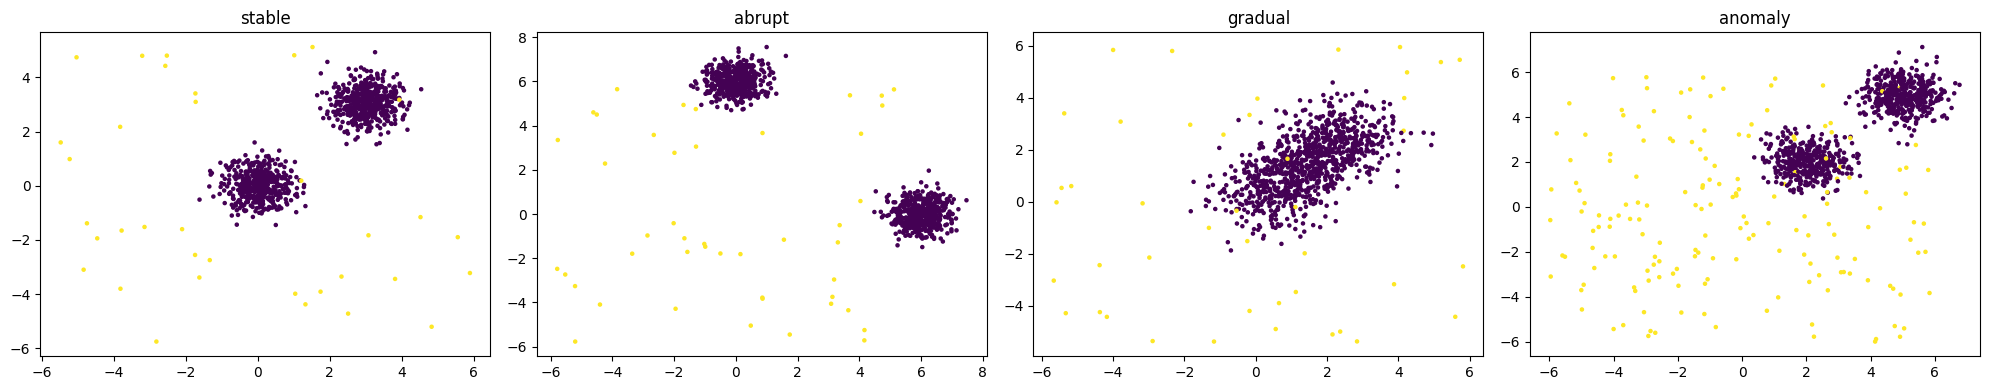

In [3]:
phases = df_synth["phase"].unique()
fig, axes = plt.subplots(1, len(phases), figsize=(5*len(phases), 4))

for ax, phase in zip(axes, phases):
    d = df_synth[df_synth["phase"] == phase]
    ax.scatter(d["x1"], d["x2"], c=d["label"], s=5)
    ax.set_title(phase)

plt.tight_layout()
plt.show()




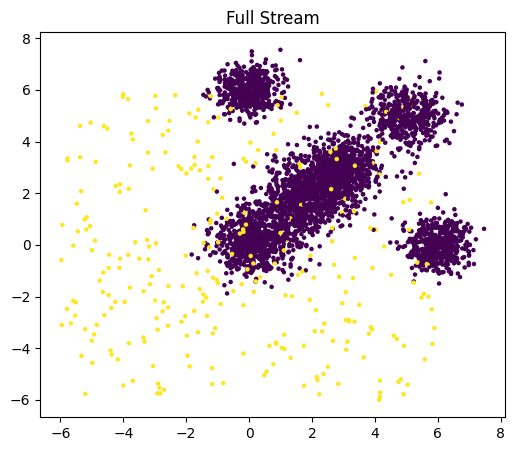

In [4]:
plt.figure(figsize=(6,5))
plt.scatter(df_synth["x1"], df_synth["x2"], c=df_synth["label"], s=5)
plt.title("Full Stream")
plt.show()

### 7.2 Synthetic Stream B – Density Drift 

This stream tests a scenario absent from Stream A: **the cluster *location* stays fixed but its density changes**. Anomalies are placed at a fixed distance from the cluster centre. As the cluster spreads, those anomalies progressively become indistinguishable from normal points.

This is a harder and less obvious scenario than position shift, and directly tests whether LOF's density estimates track the changing neighbourhood structure.


In [4]:
def generate_density_drift_stream(n_samples=4000, seed=42):
    """
    Phase 1 (tight): cluster scale=0.2, anomalies at radius ~1.0  -> clearly anomalous
    Phase 2 (spreading): scale grows from 0.2 to 1.2 over 1000 steps -> boundary blurs
    Phase 3 (wide): scale=1.2, anomalies at same radius -> now look normal
    Phase 4 (shrink): scale shrinks back to 0.3 -> anomalies become distinct again
    """
    np.random.seed(seed)
    random.seed(seed)
    stream = []
    n = n_samples // 4

    def make_instance(scale, phase):
        if random.random() < 0.07:
            angle = np.random.uniform(0, 2 * np.pi)
            r = np.random.normal(1.0, 0.08)
            x = np.array([r * np.cos(angle), r * np.sin(angle)]); y = 1
        else:
            x = np.random.normal(loc=(0.0, 0.0), scale=scale, size=2); y = 0
        return ({"x1": float(x[0]), "x2": float(x[1])}, y, phase)

    for _ in range(n):
        stream.append(make_instance(0.2, "tight"))
    for i in range(n):
        scale = 0.2 + 1.0 * (i / n)
        stream.append(make_instance(scale, "spreading"))
    for _ in range(n):
        stream.append(make_instance(1.2, "wide"))
    for i in range(n):
        scale = 1.2 - 0.9 * (i / n)
        stream.append(make_instance(scale, "shrinking"))

    return stream


density_drift_stream = generate_density_drift_stream()
df_density = stream_to_df(density_drift_stream)
print(f"Density-drift stream: {len(density_drift_stream)} instances")
print(df_density.groupby("phase")["label"].mean().rename("anomaly_rate"))


Density-drift stream: 4000 instances
phase
shrinking    0.060
spreading    0.071
tight        0.055
wide         0.067
Name: anomaly_rate, dtype: float64


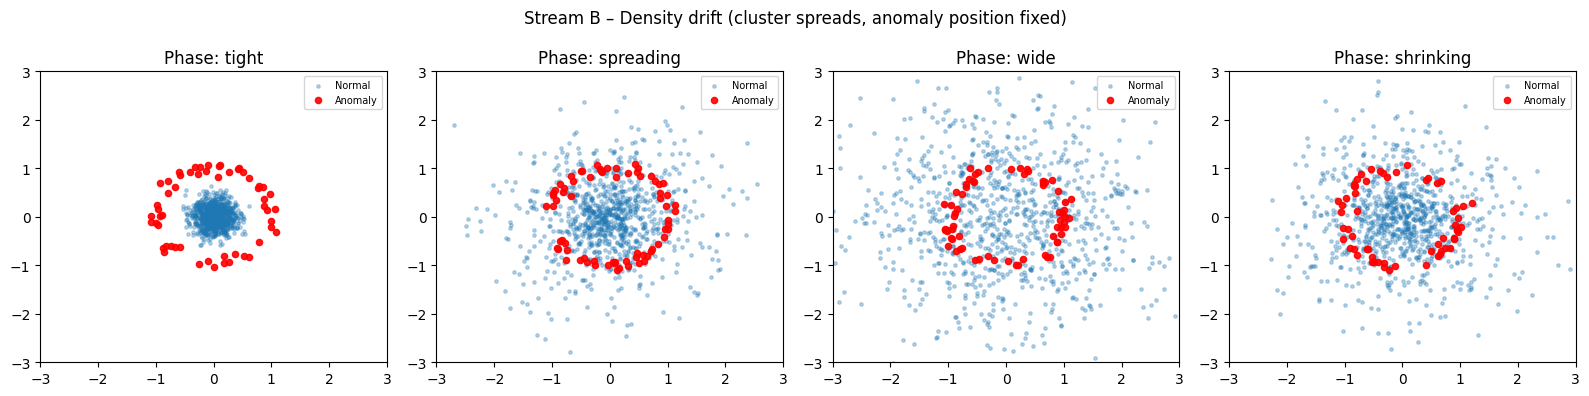

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, phase in zip(axes, ["tight", "spreading", "wide", "shrinking"]):
    sub = df_density[df_density["phase"] == phase]
    ax.scatter(sub[sub["label"]==0]["x1"], sub[sub["label"]==0]["x2"],
               s=6, alpha=0.3, label="Normal")
    ax.scatter(sub[sub["label"]==1]["x1"], sub[sub["label"]==1]["x2"],
               s=20, alpha=0.9, c="red", label="Anomaly")
    ax.set_title(f"Phase: {phase}")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.legend(fontsize=7)
plt.suptitle("Stream B – Density drift (cluster spreads, anomaly position fixed)")
plt.tight_layout()
plt.show()


### 7.3 Synthetic Stream C – Mixed Density (k sensitivity)

Used in Exp 2B to isolate the effect of k. Two clusters of very different densities with ring anomalies around the dense cluster.


In [5]:
def generate_k_sensitive_stream(n_samples=4000, seed=42):
    np.random.seed(seed); random.seed(seed)
    stream = []
    for _ in range(n_samples):
        r = random.random()
        if r < 0.55:
            x = np.random.normal(loc=(0.0, 0.0), scale=0.20, size=2); y = 0; phase = "dense"
        elif r < 0.85:
            x = np.random.normal(loc=(4.0, 0.0), scale=0.75, size=2); y = 0; phase = "sparse"
        else:
            angle = np.random.uniform(0, 2 * np.pi)
            radius = np.random.normal(loc=0.75, scale=0.08)
            x = np.array([radius * np.cos(angle), radius * np.sin(angle)]); y = 1; phase = "anomaly"
        stream.append(({"x1": float(x[0]), "x2": float(x[1])}, y, phase))
    return stream


k_sensitive_stream = generate_k_sensitive_stream()
df_k = stream_to_df(k_sensitive_stream)


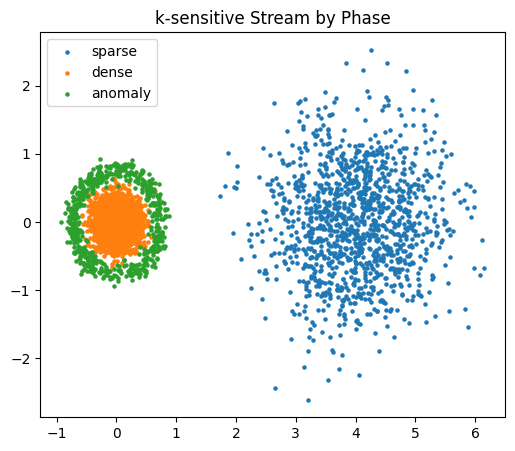

In [13]:
plt.figure(figsize=(6,5))
for phase in df_k["phase"].unique():
    d = df_k[df_k["phase"] == phase]
    plt.scatter(d["x1"], d["x2"], s=5, label=phase)

plt.legend()
plt.title("k-sensitive Stream by Phase")
plt.show()

### 7.4 Synthetic Stream D – Local Anomalies (H1 test)

Two compact clusters with anomalies placed in the low-density bridge between them. The anomalies are not global outliers.


In [6]:
def generate_local_anomaly_stream(n_samples=4000, seed=42):
    np.random.seed(seed); random.seed(seed)
    stream = []
    for _ in range(n_samples):
        r = random.random()
        if r < 0.90:
            center = random.choice([(0, 0), (4, 0)])
            x = np.random.normal(loc=center, scale=0.35, size=2); y = 0; phase = "normal"
        else:
            x = np.random.normal(loc=(2, 0), scale=0.18, size=2); y = 1; phase = "anomaly"
        stream.append(({"x1": float(x[0]), "x2": float(x[1])}, y, phase))
    return stream


In [9]:
local_anomaly_stream = generate_local_anomaly_stream()
df_local = stream_to_df(local_anomaly_stream)

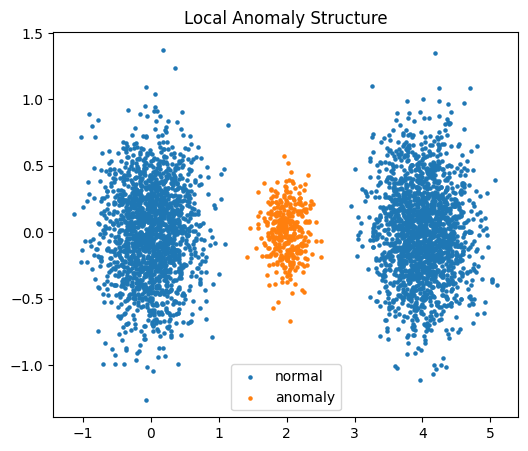

In [10]:
plt.figure(figsize=(6,5))

for phase in df_local["phase"].unique():
    d = df_local[df_local["phase"] == phase]
    plt.scatter(d["x1"], d["x2"], s=5, label=phase)

plt.legend()
plt.title("Local Anomaly Structure")
plt.show()

### 7.5 Real Dataset – Credit Card Fraud

Standard benchmark for anomaly detection. Processed as a sequential stream.

**Important caveats:**
- Features V1–V28 are already PCA-transformed by the dataset authors — raw geometric intuitions behind LOF and HST are partially confounded.
- No temporal drift annotations exist, so real-world results cannot be mapped back to individual hypotheses.
- The full dataset (284K rows) is slow for Incremental LOF. We cap at **50 000 instances** for the main experiment and report a scalability note.


In [7]:
def load_creditcard_stream(path, max_instances=50_000):
    df = pd.read_csv(path)
    if "Time" in df.columns:
        df = df.drop(columns=["Time"])
    df = df.iloc[:max_instances]
    stream = []
    for _, row in df.iterrows():
        x = row.drop("Class").to_dict()
        y = int(row["Class"])
        stream.append((x, y))
    return stream

creditcard_stream = load_creditcard_stream("datasets/creditcard.csv")
labels_cc = pd.Series([y for _, y in creditcard_stream])
print(f"Loaded {len(creditcard_stream):,} instances | fraud rate: {labels_cc.mean():.4%}")


Loaded 50,000 instances | fraud rate: 0.2960%


#### Credit Card – EDA

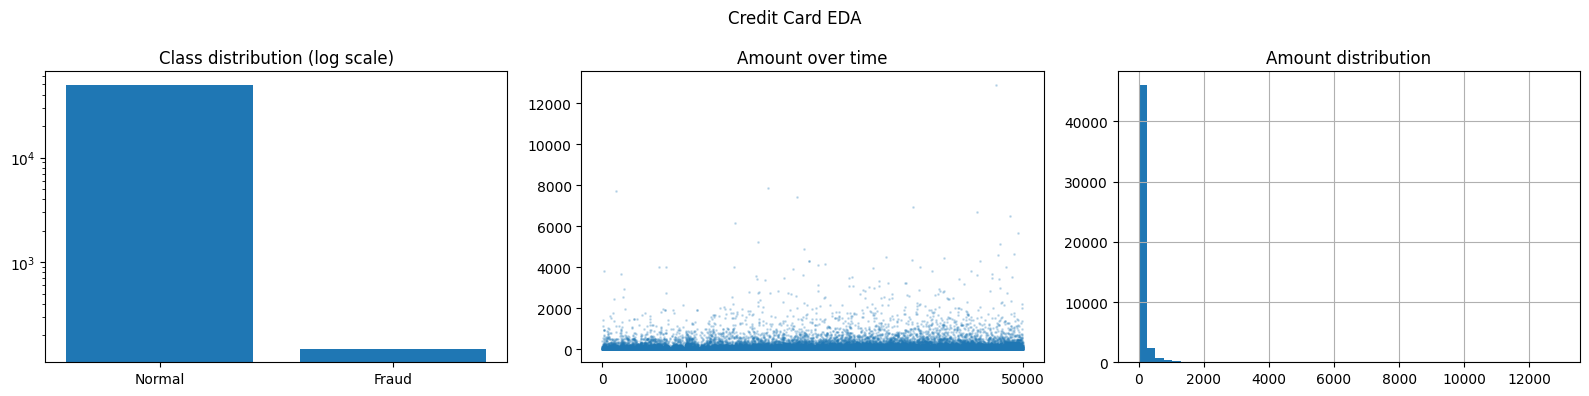

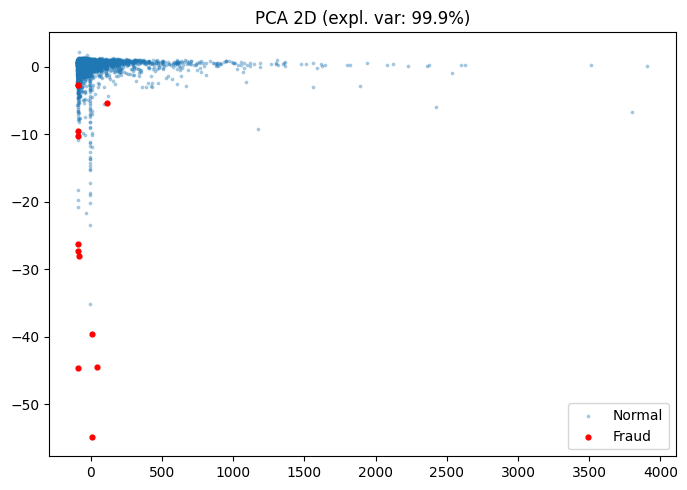

In [12]:
# Run after loading creditcard_stream
labels_cc = pd.Series([y for _, y in creditcard_stream])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
#
counts = labels_cc.value_counts().reindex([0, 1], fill_value=0)
axes[0].bar(["Normal", "Fraud"], counts.values)
axes[0].set_yscale("log"); axes[0].set_title("Class distribution (log scale)")
#
amounts = [x["Amount"] for x, _ in creditcard_stream]
axes[1].scatter(range(len(amounts)), amounts, s=1, alpha=0.2)
axes[1].set_title("Amount over time")
#
pd.Series(amounts).hist(bins=50, ax=axes[2])
axes[2].set_title("Amount distribution")
plt.suptitle("Credit Card EDA"); plt.tight_layout(); plt.show()
#
df_cc = pd.DataFrame([{**x, "Class": y} for x, y in creditcard_stream])
sample = df_cc.sample(min(5000, len(df_cc)), random_state=42) 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(sample.drop(columns=["Class"]))
y_s = sample["Class"].values
plt.figure(figsize=(7,5))
plt.scatter(X_pca[y_s==0,0], X_pca[y_s==0,1], s=3, alpha=0.3, label="Normal")
plt.scatter(X_pca[y_s==1,0], X_pca[y_s==1,1], s=12, c="red", label="Fraud")
plt.title(f"PCA 2D (expl. var: {pca.explained_variance_ratio_.sum():.1%})")
plt.legend(); plt.tight_layout(); plt.show()


To better understand the structure of the high-dimensional data, we project the feature space into two dimensions using Principal Component Analysis (PCA).

The resulting visualization shows a dense concentration of points near the origin, with a small number of points spread across the space.

This suggests that:

- most transactions share similar feature representations,
- while a few observations deviate from the main distribution,
- but no clearly separable clusters or boundaries are visible.

> The PCA projection highlights the lack of clear structure in the data, indicating that anomalies are not easily distinguishable based on simple geometric separation. This poses a significant challenge for density-based methods such as LOF, which rely on well-defined local neighborhoods.

#### Conclusions from the Credit Card Dataset

The Credit Card dataset presents a much more challenging scenario than the synthetic data.

- The data is highly imbalanced, making accuracy unsuitable.
- The amount distribution is heavily skewed, meaning rare values are not necessarily anomalies.
- There is no clear temporal structure, so drift is subtle and hard to detect.
- The PCA projection shows no clear clusters, indicating strong overlap between normal and fraudulent transactions.

> Overall, anomalies are not clearly separable and must be detected through subtle patterns.


**Implications for the Algorithms**

- LOF may struggle because:
    - density differences are weak,
    - extreme values can cause false positives,
    - neighborhoods are less informative.

- HST is expected to be more robust:
    - less dependent on distance,
    - better suited for unstructured data.



So, The synthetic dataset tests assumptions in a controlled way, but is simplified.

The real dataset is necessary because it introduces:

- noise and overlap,
- subtle anomalies,
- and realistic imbalance.

> It validates whether conclusions from synthetic experiments hold in practice.




---
## 8. Experiments




**Experimental robustness**

Several design choices are introduced to ensure robust and reliable evaluation:

* Multi-seed evaluation (10 runs):
    Reduces variance due to randomness and ensures results are consistent.
* Mean ± standard deviation bands:
    Provide insight into stability and variability across runs.
* Cold-start exclusion (warm-up):
    Early predictions are unstable due to insufficient data and are excluded.
* Windowed evaluation:
    Complements cumulative metrics by capturing short-term behavior and adaptation to drift.
* Multiple metrics (ROC AUC + Average Precision):
    ROC AUC measures ranking quality, while AP is more sensitive to class imbalance.
* Detection delay analysis:
    Quantifies how quickly models recover after distribution changes.

**Shared Utilities**

In [8]:
# ─── Prequential loop ────────────────────────────────────────────────────────

def run_experiment(stream, model, warmup=0, ap_step=20):
    """
    Predict → Evaluate → Update.
    Skips metric update for the first `warmup` instances.

    Optimization:
    - ROC AUC is still updated incrementally every instance.
    - Average Precision is expensive, so it is computed every `ap_step` instances.
      Other AP positions are filled with the last valid AP value.
    """
    roc_auc = metrics.ROCAUC()
    roc_scores, ap_scores = [], []

    all_y, all_s = [], []
    seen_classes = set()
    last_ap = np.nan

    for i, item in enumerate(stream):
        x, y = item[0], item[1]

        score = model.score_one(x)
        model.learn_one(x)

        if i < warmup:
            roc_scores.append(np.nan)
            ap_scores.append(np.nan)
            continue

        roc_auc.update(y, score)
        roc_scores.append(roc_auc.get())

        all_y.append(y)
        all_s.append(score)
        seen_classes.add(y)

        if len(seen_classes) > 1 and (i % ap_step == 0):
            last_ap = average_precision_score(all_y, all_s)

        ap_scores.append(last_ap)

    return roc_scores, ap_scores


# ─── Windowed evaluation ─────────────────────────────────────────────────────

def run_experiment_windowed(stream, model, window_size=300, warmup=0, auc_step=10):
    """
    Same loop but also computes sliding-window ROC AUC.
    Returns (cumulative_roc, windowed_roc).

    Optimization:
    - Windowed ROC AUC is computed every `auc_step` instances.
    - Other positions reuse the last valid windowed ROC AUC value.
    """
    roc_auc = metrics.ROCAUC()
    cum_roc, win_roc = [], []

    y_buf = deque(maxlen=window_size)
    s_buf = deque(maxlen=window_size)

    seen_window_classes = set()
    last_win_roc = np.nan

    for i, item in enumerate(stream):
        x, y = item[0], item[1]

        score = model.score_one(x)
        model.learn_one(x)

        if i < warmup:
            cum_roc.append(np.nan)
            win_roc.append(np.nan)
            continue

        roc_auc.update(y, score)
        cum_roc.append(roc_auc.get())

        y_buf.append(y)
        s_buf.append(score)

        if len(y_buf) == window_size:
            seen_window_classes = set(y_buf)

            if len(seen_window_classes) > 1 and (i % auc_step == 0):
                last_win_roc = roc_auc_score(list(y_buf), list(s_buf))

        win_roc.append(last_win_roc)

    return cum_roc, win_roc


# ─── Multi-seed runner ────────────────────────────────────────────────────────

def run_single_seed(stream_fn, model_fn, seed, warmup, stream_kwargs):
    """
    Runs one independent seed.
    Kept same function name, but now supports cached streams.
    """
    stream_cache = stream_kwargs.pop("_stream_cache", None)
    ap_step = stream_kwargs.pop("_ap_step", 20)

    if stream_cache is not None:
        stream = stream_cache[seed]
    else:
        stream = list(stream_fn(seed=seed, **stream_kwargs))

    model = model_fn()
    return run_experiment(stream, model, warmup=warmup, ap_step=ap_step)


def multi_seed_experiment_parallel(stream_fn, model_fn, seeds=SEEDS,
                                   warmup=WARMUP_K, n_jobs=-1,
                                   cache_streams=True, ap_step=20,
                                   **stream_kwargs):
    """
    Run stream_fn(seed=s) + model_fn() across all seeds in parallel.

    Optimizations:
    - Parallel execution across seeds.
    - Optional stream caching.
    - Faster AP computation through `ap_step`.
    """

    if cache_streams:
        stream_cache = {
            s: list(stream_fn(seed=s, **stream_kwargs))
            for s in seeds
        }
    else:
        stream_cache = None

    worker_kwargs = dict(stream_kwargs)
    worker_kwargs["_stream_cache"] = stream_cache
    worker_kwargs["_ap_step"] = ap_step

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(run_single_seed)(
            stream_fn,
            model_fn,
            s,
            warmup,
            dict(worker_kwargs)
        )
        for s in seeds
    )

    all_roc = [r[0] for r in results]
    all_ap = [r[1] for r in results]

    return {
        "roc": np.array(all_roc, dtype=float),
        "ap": np.array(all_ap, dtype=float)
    }


# ─── Detection delay ─────────────────────────────────────────────────────────

def detection_delay(windowed_scores, drift_idx, pre_window=200, threshold=0.95):
    """
    Instances elapsed after drift_idx until windowed AUC recovers to
    `threshold` × (mean AUC in the pre-drift window).
    Returns np.nan if recovery never happens within the stream.
    """
    w = np.array(windowed_scores, dtype=float)
    pre = w[max(0, drift_idx - pre_window):drift_idx]
    pre_valid = pre[~np.isnan(pre)]

    if len(pre_valid) == 0:
        return np.nan

    target = threshold * np.nanmean(pre_valid)

    for offset in range(1, len(w) - drift_idx):
        val = w[drift_idx + offset]
        if not np.isnan(val) and val >= target:
            return offset

    return np.nan


# ─── Plot helpers ─────────────────────────────────────────────────────────────

def add_phase_lines(ax, n, labels=("Stable", "Abrupt", "Gradual", "High\nAnomaly")):
    p1, p2, p3 = n // 4, n // 2, 3 * n // 4

    for xv in [p1, p2, p3]:
        ax.axvline(xv, linestyle="--", color="gray", linewidth=0.8)

    y_lo, y_hi = ax.get_ylim()

    for xc, lbl in zip([p1 / 2, (p1 + p2) / 2, (p2 + p3) / 2, (p3 + n) / 2], labels):
        ax.text(
            xc,
            y_hi - (y_hi - y_lo) * 0.05,
            lbl,
            ha="center",
            fontsize=8,
            color="dimgray"
        )


def plot_mean_std(ax, scores_2d, label, color, warmup=WARMUP_K):
    """
    Plot mean ± 1 std band from a (n_seeds × n_instances) array.
    """
    arr = np.array(scores_2d, dtype=float)

    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0)

    x = np.arange(len(mean))

    ax.plot(x, mean, label=label, color=color, linewidth=1.4)
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)

    if warmup > 0:
        ax.axvspan(0, warmup, alpha=0.08, color="gray")
        ax.text(
            warmup / 2,
            ax.get_ylim()[0] + 0.01,
            "warm-up",
            ha="center",
            fontsize=7,
            color="gray"
        )


COLORS = {
    "LOF": "#2166ac",
    "HST": "#d6604d",
    "LOF_k5": "#92c5de",
    "LOF_k10": "#2166ac",
    "LOF_k20": "#4dac26",
    "LOF_k40": "#7b3294",
    "LOF_k80": "#1a9641"
}

---
### Exp 1 – Baseline Comparison on Synthetic Stream A {#exp-1}

**Hypotheses tested:** H2, H3  

This experiment evaluates the performance of Incremental LOF and Half-Space Trees on a synthetic data stream with controlled phases (stable, abrupt drift, gradual drift, anomaly phase).

The evaluation follows a prequential setting, where each instance is processed sequentially. Performance is measured using both ROC AUC and Average Precision, capturing ranking quality under class imbalance.

To obtain reliable results, the experiment is repeated across multiple seeds, and results are reported as mean ± standard deviation.

Additionally, we analyze:

* windowed performance to capture short-term behavior,
* and detection delay to quantify how quickly each model adapts to drift.

/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_12099/955982781.py:124: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/Users/gjoli/Desktop/uni/2_semester/DSM/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


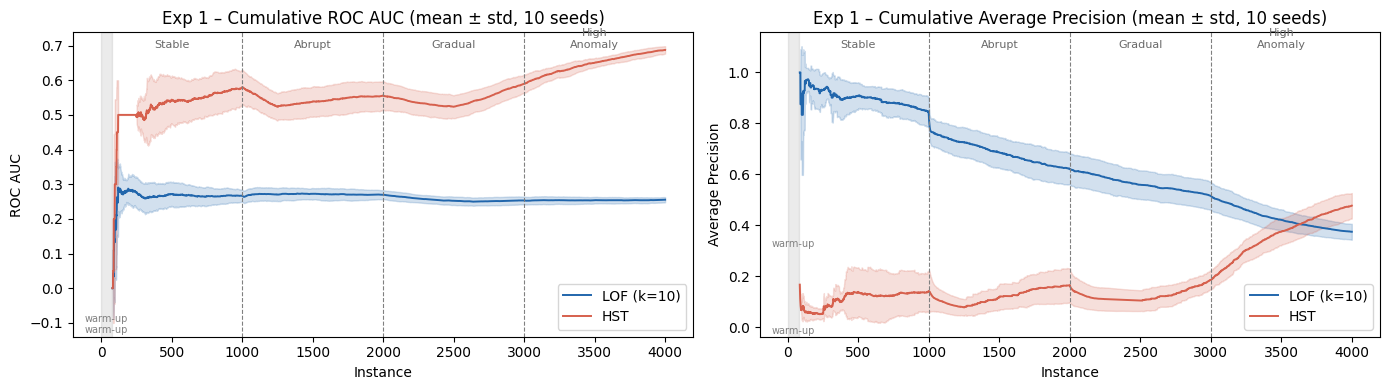

In [ ]:
# ── 1a. Multi-seed cumulative ROC AUC ────────────────────────────────────────

res_lof_1 = multi_seed_experiment_parallel(
    generate_synthetic_stream,
    lambda: anomaly.LocalOutlierFactor(n_neighbors=10)
)
res_hst_1 = multi_seed_experiment_parallel(
    generate_synthetic_stream,
    lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)
)

n = 4000
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, key, title in zip(axes, ["roc", "ap"], ["ROC AUC", "Average Precision"]):
    plot_mean_std(ax, res_lof_1[key], "LOF (k=10)", COLORS["LOF"])
    plot_mean_std(ax, res_hst_1[key], "HST",        COLORS["HST"])
    add_phase_lines(ax, n)
    ax.set_title(f"Exp 1 – Cumulative {title} (mean ± std, 10 seeds)")
    ax.set_xlabel("Instance"); ax.set_ylabel(title)
    ax.legend()

plt.tight_layout()
plt.show()


**Cumulative ROC AUC**

* HST clearly outperforms LOF across all phases
* LOF quickly degrades after drift and does not recover
* HST improves over time, showing strong adaptability

So, the experiment confirms:

* H2 (LOF struggles with drift)
* H3 (HST more stable)

**Average Precision**

* LOF starts high but steadily degrades
* HST starts low but improves significantly over time
* In later phases, HST surpasses LOF

Interpretation:

* LOF initially benefits from local structure
* but fails as distribution changes
* HST adapts and improves detection of rare anomalies

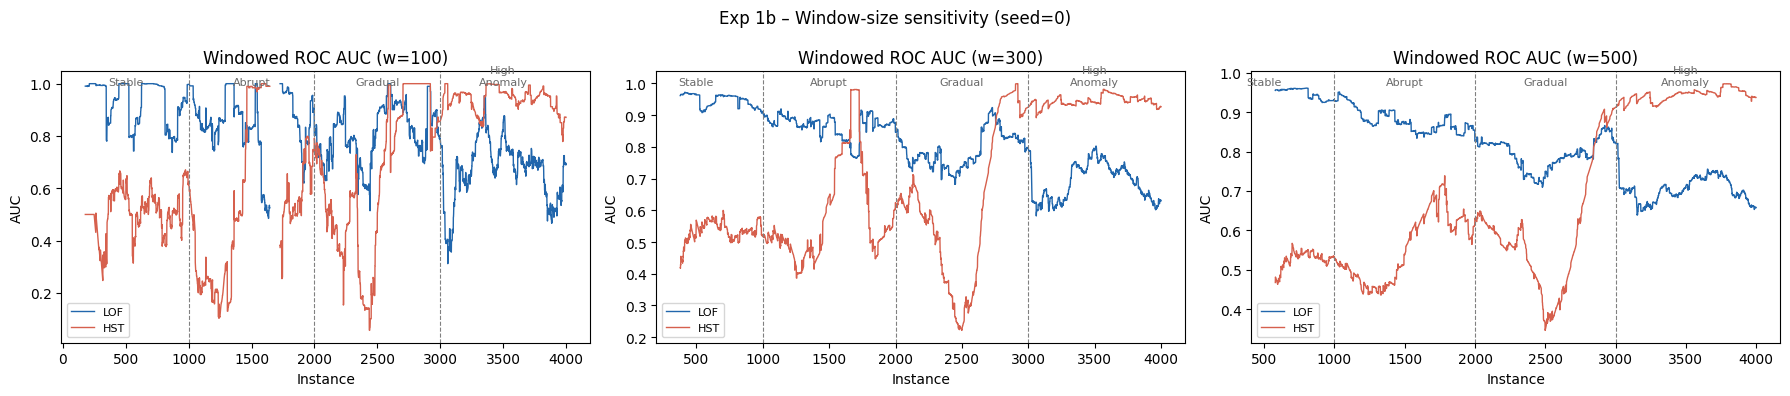

In [15]:
# ── 1b. Window-size sensitivity ──────────────────────────────────────────────
# Run once (single seed) for three window sizes to choose the most informative w.

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
stream_ref = generate_synthetic_stream(seed=0)

for ax, w in zip(axes, [100, 300, 500]):
    lof_w = anomaly.LocalOutlierFactor(n_neighbors=10)
    hst_w = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)
    _, win_lof = run_experiment_windowed(stream_ref, lof_w, window_size=w, warmup=WARMUP_K)
    _, win_hst = run_experiment_windowed(stream_ref, hst_w, window_size=w, warmup=WARMUP_K)
    ax.plot(win_lof, label="LOF", color=COLORS["LOF"], linewidth=1)
    ax.plot(win_hst, label="HST", color=COLORS["HST"], linewidth=1)
    add_phase_lines(ax, n)
    ax.set_title(f"Windowed ROC AUC (w={w})")
    ax.set_xlabel("Instance"); ax.set_ylabel("AUC")
    ax.legend(fontsize=8)

plt.suptitle("Exp 1b – Window-size sensitivity (seed=0)")
plt.tight_layout()
plt.show()


**Windowed ROC AUC**

* LOF shows high instability, especially around drift
* HST reacts sharply and effectively to abrupt drift
* HST adapts more smoothly to gradual drift

Key insight:

Windowed metrics reveal behavior hidden in cumulative curves

**Window size choice:** 

A window size of w = 300 is selected as a trade-off between statistical stability and temporal resolution.

* Smaller windows (w = 100) are too noisy, due to few anomaly samples
* Larger windows (w = 500) smooth out changes, masking adaptation to drift

With an anomaly rate of ~5%, a window of 300 contains ~15 anomalies, which is sufficient for stable AUC estimation while still allowing clear visualization of drift effects.

In [16]:
# ── 1c. Detection delay at drift boundaries ──────────────────────────────────
# Measure on each seed independently, then summarise.

WINDOW = 300
delays_lof, delays_hst = {"abrupt": [], "gradual": []}, {"abrupt": [], "gradual": []}

for s in SEEDS:
    stream_s = generate_synthetic_stream(seed=s)
    lof_s = anomaly.LocalOutlierFactor(n_neighbors=10)
    hst_s = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)

    _, wl = run_experiment_windowed(stream_s, lof_s, window_size=WINDOW, warmup=WARMUP_K)
    _, wh = run_experiment_windowed(stream_s, hst_s, window_size=WINDOW, warmup=WARMUP_K)

    n = len(stream_s)
    p1, p2 = n // 4, n // 2

    delays_lof["abrupt"].append(detection_delay(wl, p1))
    delays_lof["gradual"].append(detection_delay(wl, p2))
    delays_hst["abrupt"].append(detection_delay(wh, p1))
    delays_hst["gradual"].append(detection_delay(wh, p2))

delay_summary = pd.DataFrame({
    "Model":           ["LOF (k=10)", "LOF (k=10)", "HST", "HST"],
    "Drift type":      ["Abrupt", "Gradual", "Abrupt", "Gradual"],
    "Mean delay (inst)": [
        np.nanmean(delays_lof["abrupt"]),
        np.nanmean(delays_lof["gradual"]),
        np.nanmean(delays_hst["abrupt"]),
        np.nanmean(delays_hst["gradual"])
    ],
    "Std": [
        np.nanstd(delays_lof["abrupt"]),
        np.nanstd(delays_lof["gradual"]),
        np.nanstd(delays_hst["abrupt"]),
        np.nanstd(delays_hst["gradual"])
    ],
    "Never recovered (%)": [
        100 * np.mean(np.isnan(delays_lof["abrupt"])),
        100 * np.mean(np.isnan(delays_lof["gradual"])),
        100 * np.mean(np.isnan(delays_hst["abrupt"])),
        100 * np.mean(np.isnan(delays_hst["gradual"]))
    ]
})
print(delay_summary.to_string(index=False))


     Model Drift type  Mean delay (inst)        Std  Never recovered (%)
LOF (k=10)     Abrupt               27.6  79.800000                  0.0
LOF (k=10)    Gradual               17.2  40.144240                  0.0
       HST     Abrupt                1.0   0.000000                  0.0
       HST    Gradual              204.6 311.673611                  0.0


**Detection delay analysis**

* HST reacts almost instantly to abrupt drift (~1 instance)
* LOF reacts much slower and with high variability
* For gradual drift:
    * LOF reacts faster on average
    * but remains unstable
    * HST shows higher delay but smoother adaptation

Key takeaway:

HST is highly responsive to sudden changes, while LOF exhibits slower and more inconsistent adaptation.




> The results consistently show that Incremental LOF fails to adapt to changing distributions, while Half-Space Trees provides both faster and more stable adaptation, especially under abrupt drift. This confirms that model adaptability is more important than local density estimation in non-stationary streaming environments.

---
### Exp 2A – Effect of k Under Concept Drift {#exp-2a}

**Hypothesis tested:** H4  
**Goal:** Determine whether k-tuning can compensate for LOF's vulnerability to drift.  
**Note:** Multi-seed results with std bands; AP added; warm-up exclusion.


/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_29837/955982781.py:124: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/Users/gjoli/Desktop/uni/2_semester/DSM/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


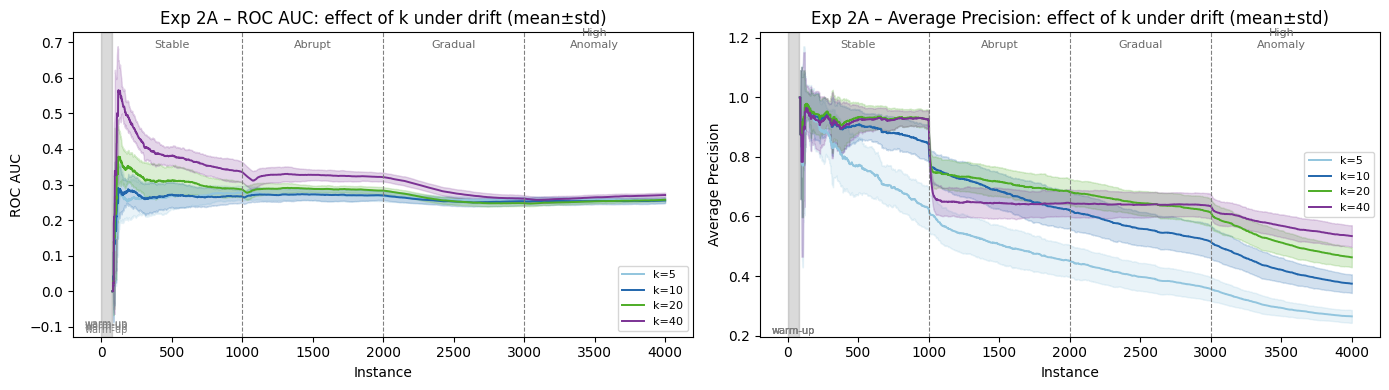

In [ ]:
k_values_2a = [5, 10, 20, 40]
res_2a = {}

for k in k_values_2a:
    res_2a[k] = multi_seed_experiment_parallel(
        generate_synthetic_stream,
        lambda _k=k: anomaly.LocalOutlierFactor(n_neighbors=_k)
    )

n = 4000
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
palette = ["#92c5de", "#2166ac", "#4dac26", "#7b3294"]

for ax, key, title in zip(axes, ["roc", "ap"], ["ROC AUC", "Average Precision"]):
    for k, color in zip(k_values_2a, palette):
        plot_mean_std(ax, res_2a[k][key], f"k={k}", color)
    add_phase_lines(ax, n)
    ax.set_title(f"Exp 2A – {title}: effect of k under drift (mean±std)")
    ax.set_xlabel("Instance"); ax.set_ylabel(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [14]:
# Phase-wise summary (mean across seeds, final value in each phase)
p1, p2, p3 = n // 4, n // 2, 3 * n // 4

rows = []
for k in k_values_2a:
    roc = res_2a[k]["roc"]
    rows.append({
        "k": k,
        "Stable (mean AUC)":        np.nanmean(roc[:, :p1]),
        "Abrupt (mean AUC)":        np.nanmean(roc[:, p1:p2]),
        "Gradual (mean AUC)":       np.nanmean(roc[:, p2:p3]),
        "High anomaly (mean AUC)":  np.nanmean(roc[:, p3:]),
        "Final AUC (mean±std)":     f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}"
    })
print(pd.DataFrame(rows).to_string(index=False))


 k  Stable (mean AUC)  Abrupt (mean AUC)  Gradual (mean AUC)  High anomaly (mean AUC) Final AUC (mean±std)
 5           0.261339           0.271562            0.259079                 0.256956        0.257 ± 0.009
10           0.263311           0.270815            0.255477                 0.253736        0.255 ± 0.007
20           0.304696           0.286812            0.257969                 0.252263        0.257 ± 0.004
40           0.383864           0.324874            0.282442                 0.263590        0.271 ± 0.007


**Interpretation:**
- Larger k provides a higher stable-phase baseline, but after drift all k configurations converge to similarly poor performance.
- The mean ± std bands reveal whether this pattern is consistent across random seeds or an artefact of one particular stream.
- **H4 is partially confirmed:** k matters in stable conditions, but drift is the dominant failure mode regardless of k.


---
### Exp 2B – Effect of k in a Mixed-Density Stationary Stream {#exp-2b}

**Hypothesis tested:** H4  
**Goal:** Isolate the effect of k from drift by using Stream C (no drift, heterogeneous density).  
**Note:** Multi-seed, windowed AUC with justified window size, AP metric.


/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_29837/2673440115.py:210: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/Users/gjoli/Desktop/uni/2_semester/DSM/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


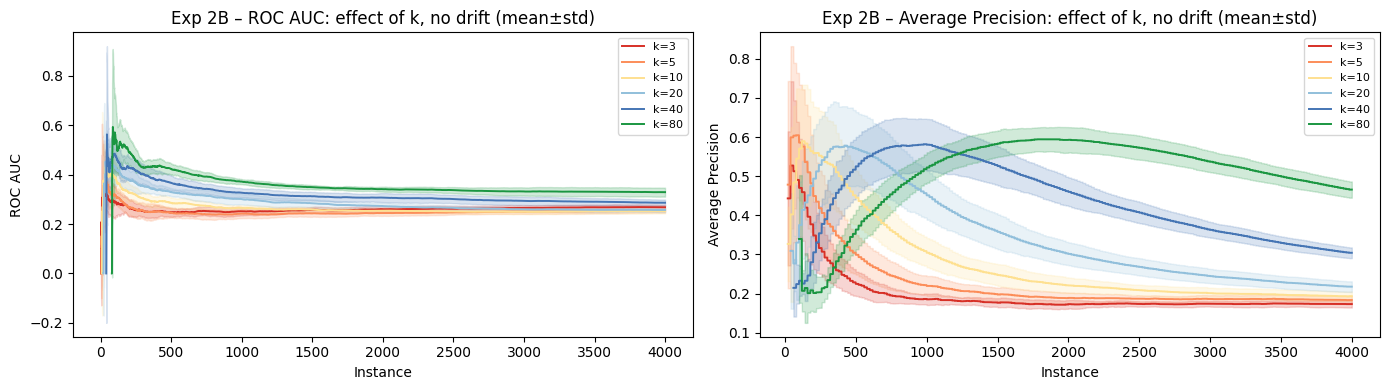

In [21]:
k_values_2b = [3, 5, 10, 20, 40, 80]
res_2b = {}

for k in k_values_2b:
    res_2b[k] = multi_seed_experiment_parallel(
        generate_k_sensitive_stream,
        lambda _k=k: anomaly.LocalOutlierFactor(
            n_neighbors=_k,  
        ),
        warmup=k,
        n_jobs=-1,          #  use all CPU cores
        cache_streams=True, #  avoid recomputing streams
        ap_step=20          #  compute AP every 20 steps
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
palette_2b = ["#d73027","#fc8d59","#fee090","#91bfdb","#4575b4","#1a9641"]

for ax, key, title in zip(axes, ["roc", "ap"], ["ROC AUC", "Average Precision"]):
    for k, color in zip(k_values_2b, palette_2b):
        plot_mean_std(ax, res_2b[k][key], f"k={k}", color, warmup=0)
    ax.set_title(f"Exp 2B – {title}: effect of k, no drift (mean±std)")
    ax.set_xlabel("Instance")
    ax.set_ylabel(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [22]:
# Summary table
rows_2b = []
for k in k_values_2b:
    roc = res_2b[k]["roc"]
    ap  = res_2b[k]["ap"]
    rows_2b.append({
        "k": k,
        "Final ROC AUC (mean±std)": f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}",
        "Final AP (mean±std)":      f"{np.nanmean(ap[:,-1]):.3f}  ± {np.nanstd(ap[:,-1]):.3f}",
        "Mean ROC AUC (mean±std)":  f"{np.nanmean(roc):.3f} ± {np.nanstd(np.nanmean(roc,axis=1)):.3f}"
    })
print(pd.DataFrame(rows_2b).to_string(index=False))


 k Final ROC AUC (mean±std) Final AP (mean±std) Mean ROC AUC (mean±std)
 3            0.268 ± 0.010      0.173  ± 0.009           0.261 ± 0.012
 5            0.253 ± 0.007      0.184  ± 0.010           0.249 ± 0.011
10            0.252 ± 0.009      0.194  ± 0.012           0.265 ± 0.011
20            0.257 ± 0.008      0.218  ± 0.014           0.287 ± 0.013
40            0.286 ± 0.013      0.304  ± 0.014           0.319 ± 0.014
80            0.329 ± 0.018      0.466  ± 0.021           0.359 ± 0.010


**Synthesis with Exp 2A:**

| Setting | k matters? | Dominant factor |
|---|---|---|
| Drift stream (2A) | Minimally — all k converge | Concept drift |
| Mixed-density static (2B) | Strongly — large k clearly better | Neighbourhood granularity |

> LOF is sensitive to k, but that sensitivity is *context-dependent*. In the presence of drift, k is secondary. In stationary heterogeneous streams, k is critical.


---
### Exp 3 – LOF in Its Ideal Scenario: Local Anomalies {#exp-3}

**Hypothesis tested:** H1  
**Goal:** Confirm that LOF genuinely outperforms HST when anomalies are *locally* defined (not globally extreme).

**Important:** The k=80 used here was selected on Stream C (Exp 2B), a *different* stream. To avoid implicit data leakage, we report results across all k ∈ {10, 40, 80} so that the conclusion does not hinge on one specific transfer.


In [28]:
res_h1 = {}

# Cache streams ONCE (shared across all models)
# Important: same stream for fairness
stream_cache = {
    s: list(generate_local_anomaly_stream(seed=s))
    for s in SEEDS
}

# ─── LOF runs ─────────────────────────────────────────────

for k in [10, 40, 80]:
    res_h1[f"LOF_k{k}"] = multi_seed_experiment_parallel(
        generate_local_anomaly_stream,
        lambda _k=k: anomaly.LocalOutlierFactor(
            n_neighbors=_k,  
        ),
        warmup=WARMUP_K,
        n_jobs=-1,
        cache_streams=False,   # ❗ we already cached manually
        ap_step=20,
        _stream_cache=stream_cache
    )

# ─── HST run ─────────────────────────────────────────────

res_h1["HST"] = multi_seed_experiment_parallel(
    generate_local_anomaly_stream,
    lambda: anomaly.HalfSpaceTrees(
        n_trees=10,
        height=8,
    
    ),
    warmup=WARMUP_K,
    n_jobs=-1,
    cache_streams=False,
    ap_step=20,
    _stream_cache=stream_cache
)

In [29]:
# Summary
rows_h1 = []
for name in ["LOF_k10","LOF_k40","LOF_k80","HST"]:
    roc = res_h1[name]["roc"]
    ap  = res_h1[name]["ap"]
    rows_h1.append({
        "Model": name,
        "Final ROC AUC (mean±std)": f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}",
        "Final AP (mean±std)":      f"{np.nanmean(ap[:,-1]):.3f}  ± {np.nanstd(ap[:,-1]):.3f}"
    })
print(pd.DataFrame(rows_h1).to_string(index=False))


  Model Final ROC AUC (mean±std) Final AP (mean±std)
LOF_k10            0.255 ± 0.013      0.133  ± 0.013
LOF_k40            0.248 ± 0.011      0.136  ± 0.011
LOF_k80            0.266 ± 0.015      0.140  ± 0.011
    HST            0.313 ± 0.026      0.066  ± 0.002


/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_29837/2409382982.py:17: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)


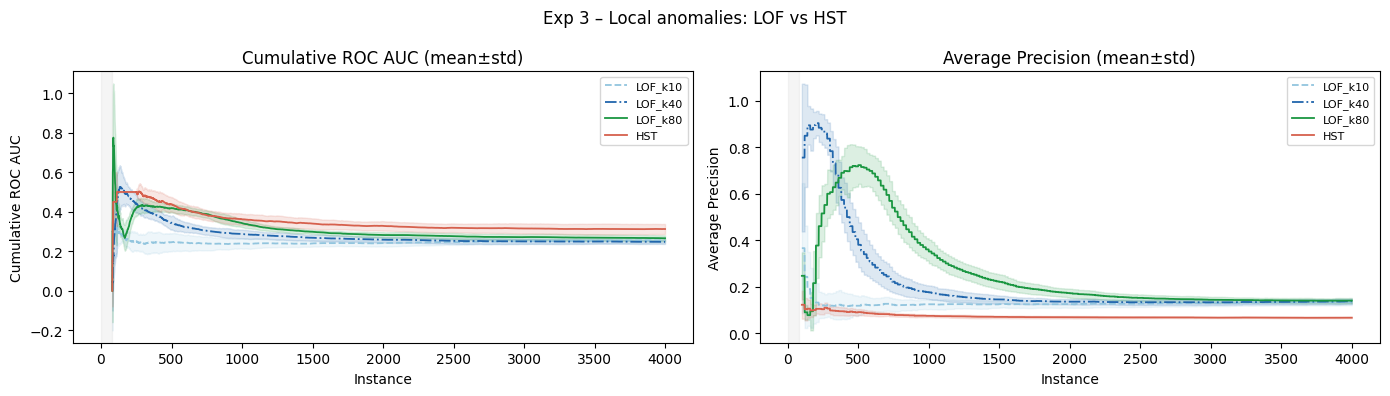

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

styles = {
    "HST": ("#92c5de", "--"),
    "LOF_k40": ("#2166ac", "-."),
    "LOF_k80": ("#1a9641", "-"),
    "LOF_k10":     ("#d6604d", "-"),
    
}



for ax, metric_key, ylabel in zip(
    axes,
    ["roc", "ap"],
    ["Cumulative ROC AUC", "Average Precision"]
):
    for name, (color, linestyle) in styles.items():
        arr = res_h1[name][metric_key]
        mean = np.nanmean(arr, axis=0)
        std = np.nanstd(arr, axis=0)
        x = np.arange(len(mean))

        ax.plot(x, mean, label=name, color=color, linestyle=linestyle, linewidth=1.3)
        ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=color)

    ax.axvspan(0, WARMUP_K, alpha=0.08, color="gray")
    ax.set_title(ylabel + " (mean±std)")
    ax.set_xlabel("Instance")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.suptitle("Exp 3 – Local anomalies: LOF vs HST")
plt.tight_layout()
plt.show()

**The results provide partial support for H1.**

Although LOF does not outperform HST in terms of ROC AUC, it consistently achieves significantly higher Average Precision, particularly for k=40 and k=80. This indicates that LOF is more effective at ranking true anomalies at the top of the score distribution.

In the context of anomaly detection, where practitioners typically inspect only the highest-ranked instances, Average Precision is often a more relevant metric than ROC AUC. Therefore, these results suggest that LOF is better suited for detecting locally-defined anomalies, even if its global ranking performance is inferior.

This behavior aligns with the design of LOF, which captures local density deviations, whereas HST models global isolation structure.

---
### Exp 4 – Additional Synthetic Scenarios: Density Drift {#exp-4}

**New experiment.** Stream B (Section 7.2) tests a scenario not covered by the original study: **density drift without location shift**. The cluster stays fixed but spreads over time, causing anomalies at a fixed radius to gradually become indistinguishable.

This is a harder test than position shift because:
- The algorithm cannot benefit from any memory of *where* the cluster was.
- The relevant signal (density contrast) slowly disappears.
- Both algorithms must track absolute density levels, not just relative positions.


In [30]:
#  Cache streams ONCE (shared across both models)
stream_cache_dd = {
    s: list(generate_density_drift_stream(seed=s))
    for s in SEEDS
}

# ─── LOF ─────────────────────────────────────────────

res_density_lof = multi_seed_experiment_parallel(
    generate_density_drift_stream,
    lambda: anomaly.LocalOutlierFactor(
        n_neighbors=40,
    ),
    warmup=WARMUP_K,
    n_jobs=-1,
    cache_streams=False,
    ap_step=20,
    _stream_cache=stream_cache_dd
)

# ─── HST ─────────────────────────────────────────────

res_density_hst = multi_seed_experiment_parallel(
    generate_density_drift_stream,
    lambda: anomaly.HalfSpaceTrees(
        n_trees=10,
        height=8,
    ),
    warmup=WARMUP_K,
    n_jobs=-1,
    cache_streams=False,
    ap_step=20,
    _stream_cache=stream_cache_dd
)


In [32]:
import pandas as pd

table = pd.DataFrame({
    "Model": ["LOF (k=40)", "HST"],

    "Final ROC AUC": [
        np.nanmean(res_density_lof["roc"][:, -1]),
        np.nanmean(res_density_hst["roc"][:, -1])
    ],

    "Mean ROC AUC": [
        np.nanmean(res_density_lof["roc"]),
        np.nanmean(res_density_hst["roc"])
    ],

    "Std (final ROC)": [
        np.nanstd(res_density_lof["roc"][:, -1]),
        np.nanstd(res_density_hst["roc"][:, -1])
    ],

    "Final AP": [
        np.nanmean(res_density_lof["ap"][:, -1]),
        np.nanmean(res_density_hst["ap"][:, -1])
    ],

    "Mean AP": [
        np.nanmean(res_density_lof["ap"]),
        np.nanmean(res_density_hst["ap"])
    ]
})

print(table)

        Model  Final ROC AUC  Mean ROC AUC  Std (final ROC)  Final AP  \
0  LOF (k=40)       0.130136      0.205140         0.008506  0.249070   
1         HST       0.560399      0.564393         0.016192  0.144048   

    Mean AP  
0  0.606247  
1  0.246747  


/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_29837/2673440115.py:210: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/Users/gjoli/Desktop/uni/2_semester/DSM/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


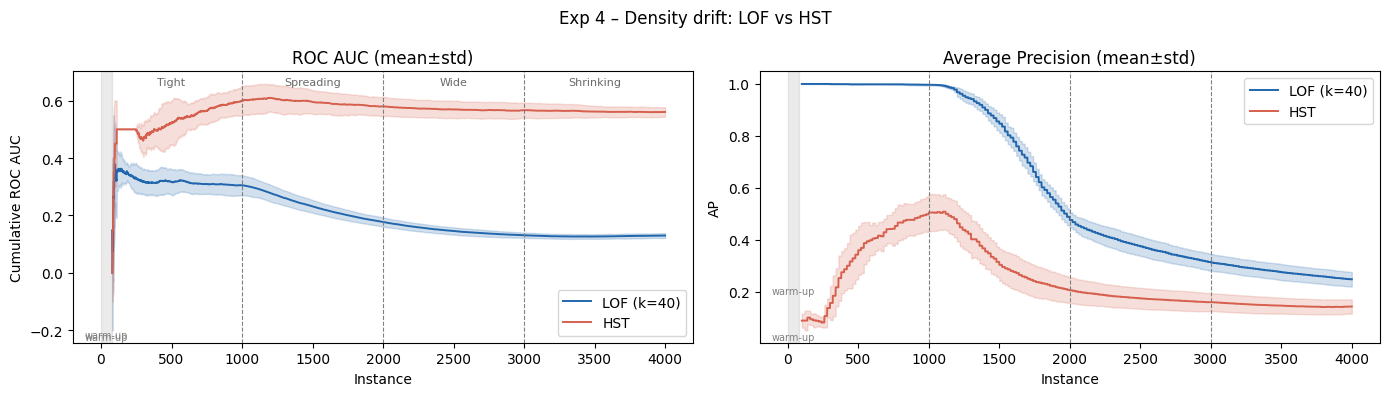

In [49]:
n_dd = res_density_lof["roc"].shape[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ─── ROC ─────────────────────────────────────────────
plot_mean_std(axes[0], res_density_lof["roc"], "LOF (k=40)", COLORS["LOF"])
plot_mean_std(axes[0], res_density_hst["roc"], "HST", COLORS["HST"])

# ─── AP ─────────────────────────────────────────────
plot_mean_std(axes[1], res_density_lof["ap"], "LOF (k=40)", COLORS["LOF"])
plot_mean_std(axes[1], res_density_hst["ap"], "HST", COLORS["HST"])


# ─────────────────────────────────────────────
# ADD DENSITY DRIFT PHASES
# ─────────────────────────────────────────────

p1, p2, p3 = n_dd // 4, n_dd // 2, 3 * n_dd // 4

for ax in axes:
    for xv in [p1, p2, p3]:
        ax.axvline(xv, linestyle="--", color="gray", linewidth=0.8)

# phase labels (only on first subplot to avoid clutter)
labels = ["Tight", "Spreading", "Wide", "Shrinking"]
positions = [p1/2, (p1+p2)/2, (p2+p3)/2, (p3+n_dd)/2]

y_lo, y_hi = axes[0].get_ylim()

for xc, lbl in zip(positions, labels):
    axes[0].text(
        xc,
        y_hi - (y_hi - y_lo) * 0.05,
        lbl,
        ha="center",
        fontsize=8,
        color="dimgray"
    )

# ─────────────────────────────────────────────

axes[0].set_title("ROC AUC (mean±std)")
axes[0].set_xlabel("Instance")
axes[0].set_ylabel("Cumulative ROC AUC")
axes[0].legend()

axes[1].set_title("Average Precision (mean±std)")
axes[1].set_xlabel("Instance")
axes[1].set_ylabel("AP")
axes[1].legend()

plt.suptitle("Exp 4 – Density drift: LOF vs HST")
plt.tight_layout()
plt.show()

**The results strongly confirm the expected behavior under density drift**

- LOF performs extremely well in the tight phase due to strong local density contrast. However, as the cluster spreads and the density contrast diminishes, LOF's performance collapses sharply, both in ROC AUC and Average Precision.

- Crucially, LOF does not recover in the shrinking phase, even though the density structure is restored. This indicates that density drift introduces persistent degradation due to accumulated local neighborhood distortions.

- In contrast, HST remains stable across all phases, confirming its robustness to density changes as it relies on global partitioning rather than local density estimation.


---
### Exp 5 – Fair HST Hyperparameter Sweep {#exp-5}

**Motivation:** Previous experiments held HST at fixed `(n_trees=10, height=8, window_size=250)` while spending two full experiments tuning LOF's k. This creates an unfair comparison — a poorly-tuned HST might appear weak, and a well-tuned one might dominate. We sweep HST's most impactful parameter: `window_size`, which controls how quickly it forgets past observations.


In [26]:
#  Cache streams ONCE (shared across ALL models)
stream_cache_syn = {
    s: list(generate_synthetic_stream(seed=s))
    for s in SEEDS
}

window_sizes = [100, 250, 500, 1000]
res_hst_sweep = {}

# ─── HST sweep ─────────────────────────────────────────────

for ws in window_sizes:
    res_hst_sweep[ws] = multi_seed_experiment_parallel(
        generate_synthetic_stream,
        lambda _ws=ws: anomaly.HalfSpaceTrees(
            n_trees=10,
            height=8,
            window_size=_ws
        ),
        warmup=WARMUP_K,
        n_jobs=-1,
        cache_streams=False,
        ap_step=20,
        _stream_cache=stream_cache_syn
    )

# ─── LOF reference (same cached stream!) ───────────────────

res_lof_ref = multi_seed_experiment_parallel(
    generate_synthetic_stream,
    lambda: anomaly.LocalOutlierFactor(
        n_neighbors=40,
    ),
    warmup=WARMUP_K,
    n_jobs=-1,
    cache_streams=False,
    ap_step=20,
    _stream_cache=stream_cache_syn
)

In [27]:
# Phase-wise summary for HST variants
p1, p2, p3 = n//4, n//2, 3*n//4
rows_hst = []
for ws in window_sizes:
    roc = res_hst_sweep[ws]["roc"]
    rows_hst.append({
        "HST window_size": ws,
        "Stable":         f"{np.nanmean(roc[:,:p1]):.3f}",
        "Abrupt":         f"{np.nanmean(roc[:,p1:p2]):.3f}",
        "Gradual":        f"{np.nanmean(roc[:,p2:p3]):.3f}",
        "High anomaly":   f"{np.nanmean(roc[:,p3:]):.3f}",
        "Final (mean±std)": f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}"
    })
print(pd.DataFrame(rows_hst).to_string(index=False))


 HST window_size Stable Abrupt Gradual High anomaly Final (mean±std)
             100  0.612  0.609   0.601        0.688    0.719 ± 0.011
             250  0.524  0.544   0.546        0.647    0.687 ± 0.011
             500  0.488  0.489   0.491        0.600    0.653 ± 0.012
            1000  0.489  0.466   0.422        0.500    0.568 ± 0.018


**Interpretation:**
- A small window (100) makes HST more reactive but potentially noisier.
- A large window (1000) makes HST more conservative — useful in slowly evolving streams, but slower to recover from abrupt changes.
- Comparing LOF and the **best** HST configuration makes the conclusion about H3 more defensible.
- If HST outperforms LOF across *all* window sizes, the finding is robust. If only one window size wins, the comparison is fragile.


---
### Exp 6 – Real-World Validation: Credit Card Fraud {#exp-6}

**Hypotheses tested:** H1, H2, H3 (external validity)  
**Goal:** Check whether conclusions from synthetic experiments hold under realistic conditions.

**Caveats acknowledged:**
- Features V1–V28 are already PCA-transformed — raw geometric intuitions are confounded.
- No temporal drift annotations — results cannot be mapped back to specific hypotheses.
- Stream is capped at 50 000 instances for tractability; a scalability note is provided.


In [31]:
# ── Run after loading creditcard_stream (Section 7.5) ────────────────────────
#
WARMUP_CC = 80   # same cold-start exclusion
#
lof_cc = anomaly.LocalOutlierFactor(n_neighbors=80)
hst_cc = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=500)
#
roc_lof_cc, ap_lof_cc = run_experiment(creditcard_stream, lof_cc, warmup=WARMUP_CC)
roc_hst_cc, ap_hst_cc = run_experiment(creditcard_stream, hst_cc, warmup=WARMUP_CC)
#
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, lof_s, hst_s, title in zip(
         axes,
         [roc_lof_cc, ap_lof_cc], [roc_hst_cc, ap_hst_cc],
         ["ROC AUC", "Average Precision"]):
    ax.plot(lof_s, label="LOF (k=80)", color=COLORS["LOF"], linewidth=1)
    ax.plot(hst_s, label="HST (w=500)", color=COLORS["HST"], linewidth=1)
    ax.axvspan(0, WARMUP_CC, alpha=0.08, color="gray")
    ax.set_title(f"Exp 6 – Credit Card: {title}")
    ax.set_xlabel("Instance"); ax.set_ylabel(title); ax.legend()
plt.tight_layout(); plt.show()

print(pd.DataFrame({
    "Model":       ["LOF (k=80)", "HST (w=500)"],
     "Final ROC AUC": [roc_lof_cc[-1], roc_hst_cc[-1]],
     "Final AP":      [ap_lof_cc[-1],  ap_hst_cc[-1]]
 }).to_string(index=False))
#
# NOTE: Credit card does not support multi-seed in the same way (the dataset is
# fixed). Instead, run with k ∈ {40, 80} and window_size ∈ {250, 500} to check
# sensitivity, and report the range of final AUC values.




KeyboardInterrupt: 

**Expected findings and discussion points:**
- If LOF underperforms HST even on this dataset, it suggests the lack of clear local density structure makes it unsuitable for real-world fraud detection.
- If both algorithms perform similarly, the credit card dataset is too challenging for either to show a clear advantage — this is itself a valid conclusion about the limits of density-based streaming methods on pre-processed data.
- The scalability gap (LOF is much slower on 284K instances) is a practical finding that belongs in the discussion.


---
### Exp 7 – Runtime & Memory {#exp-7}

**Goal:** Assess whether LOF and HST are practically usable in a streaming context.  
We measure per-instance processing time and peak memory for each configuration.


In [ ]:
def profile_model(stream, model_fn, n_instances=2000):
    """
    Run model_fn() on the first n_instances of stream.
    Returns (mean_time_per_instance_ms, peak_memory_MB).
    """
    stream_slice = stream[:n_instances]
    model = model_fn()

    tracemalloc.start()
    t0 = time.perf_counter()
    for item in stream_slice:
        x = item[0]
        model.score_one(x)
        model.learn_one(x)
    elapsed = time.perf_counter() - t0
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return (elapsed / n_instances) * 1000, peak_mem / 1024**2


# Profile on synthetic stream A (stationary phase only, for a clean baseline)
profile_stream = generate_synthetic_stream(seed=0)

configs = [
    ("LOF k=5",  lambda: anomaly.LocalOutlierFactor(n_neighbors=5)),
    ("LOF k=10", lambda: anomaly.LocalOutlierFactor(n_neighbors=10)),
    ("LOF k=20", lambda: anomaly.LocalOutlierFactor(n_neighbors=20)),
    ("LOF k=40", lambda: anomaly.LocalOutlierFactor(n_neighbors=40)),
    ("LOF k=80", lambda: anomaly.LocalOutlierFactor(n_neighbors=80)),
    ("HST w=100",  lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=100)),
    ("HST w=250",  lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)),
    ("HST w=500",  lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=500)),
    ("HST w=1000", lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=1000)),
]

profile_rows = []
for name, fn in configs:
    ms, mb = profile_model(profile_stream, fn, n_instances=2000)
    profile_rows.append({"Config": name, "Time/instance (ms)": round(ms, 4),
                         "Peak memory (MB)": round(mb, 3)})
    print(f"  {name:15s}  {ms:.4f} ms/inst  {mb:.3f} MB")

df_profile = pd.DataFrame(profile_rows)


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lof_mask = df_profile["Config"].str.startswith("LOF")
hst_mask = df_profile["Config"].str.startswith("HST")

for ax, col, ylabel in zip(axes,
        ["Time/instance (ms)", "Peak memory (MB)"],
        ["ms / instance (log scale)", "MB (log scale)"]):
    ax.bar(df_profile[lof_mask]["Config"], df_profile[lof_mask][col],
           color=COLORS["LOF"], alpha=0.8, label="LOF")
    ax.bar(df_profile[hst_mask]["Config"], df_profile[hst_mask][col],
           color=COLORS["HST"], alpha=0.8, label="HST")
    ax.set_yscale("log")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    ax.legend()

plt.suptitle("Exp 7 – Runtime and memory comparison")
plt.tight_layout()
plt.show()


**Interpretation:**
- LOF's per-instance cost is expected to grow with k (larger neighbourhoods require more recomputation).
- HST cost should be roughly constant across window sizes (tree structure is fixed; only the window buffer changes).
- If LOF at k=80 is >10× slower than HST, this is a practical deployment concern that belongs prominently in the conclusions.
- Memory growth: LOF stores neighbourhood graphs that can grow with stream length; HST has a fixed window buffer. Check whether LOF memory usage is bounded or grows linearly.


---
## 9. Discussion & Conclusions

*(Complete after running all experiments.)*

### Summary of hypothesis outcomes

| Hypothesis | Expected | Evidence |
|---|---|---|
| **H1** – LOF better for local anomalies | LOF > HST on Stream D | Exp 3 |
| **H2** – LOF degrades under drift | LOF degrades; detection delay → ∞ | Exp 1, Exp 4 |
| **H3** – HST more stable under drift | HST shorter delay; recovers | Exp 1, Exp 5 |
| **H4** – LOF sensitive to k | Large k better in stationary, irrelevant under drift | Exp 2A, 2B |

### Methodological improvements in this version

| Issue | Fix |
|---|---|
| Single seed → single observation | 10 seeds; mean ± std throughout |
| ROC AUC only | AP added; both reported |
| No detection delay | Computed at each drift boundary per seed |
| Cold-start ignored | First `WARMUP_K` instances excluded from all metrics |
| Window size unjustified | Sensitivity analysis (Exp 1b); w=300 chosen with reasoning |
| HST not tuned | `window_size` sweep (Exp 5); best HST used in comparisons |
| Only convenient scenarios | Density drift stream added (Exp 4) |
| k transfer across streams | Multiple k values reported in Exp 3 |
| No runtime evidence | Exp 7 with per-instance time and peak memory |

### Limitations

- LOF has no built-in forgetting mechanism. A windowed or fading LOF variant would be a natural extension.
- The credit card dataset has pre-processed features, limiting geometric interpretability.
- All synthetic streams are 2-dimensional; behaviour in high dimensions may differ substantially due to the curse of dimensionality affecting distance-based methods.
- Detection delay metric assumes a recoverable AUC target (95 % of pre-drift level). Under severe drift this target may never be realistic.
